# Quickstart, with everything named

This is the eight-step quickstart again — same model, same 5 x 5 grid, same
D-optimal criterion — with one thing added: **everything in this problem that
can be given a name has one.**

Nothing here changes the design. The optimal candidates, the efforts and the
criterion value are identical to `pydex_quickstart.ipynb`. What changes is
whether you can read the output without a decoder ring.

Run the quickstart first if you have not. This notebook assumes you know what
the eight steps are and only dwells on labelling.

## Why bother

Labels are optional to the mathematics and close to essential in practice, for
three reasons:

1. **Reports and plots become readable.** `Time-invariant Control 0` tells you
   nothing; `x1 [coded]` tells you what to set on the rig.
2. **Unset labels do not look broken.** pydex fills anything you leave unset
   with a generated default — `Model Parameter 0`, `Time-invariant Control 0`,
   `Response 0`, `Candidate 0` — so an unlabelled run still prints something
   plausible. That is exactly why it goes unnoticed. The quickstart's output
   is what that looks like; this notebook is the same run with labels.

## What can be named here

This model has two controls, one response and three model parameters, so five
labelling attributes apply:

| attribute | one per | where it shows up |
|---|---|---|
| `model_parameter_names` | model parameter | report, plot axes |
| `response_names` | response | plot axes |
| `ti_controls_names` | time-invariant control | design-table column headings, effort-plot axes |
| `model_parameter_unit_names` | model parameter | appended to parameter axis labels |
| `response_unit_names` | response | appended to response axis labels |

## Step 1: Import

In [1]:
from pydex.core.designer import Designer
import numpy as np

## Step 2: The model

Unchanged from the quickstart: a first-order response surface in two factors.

$$y = \theta_0 + \theta_1 x_1 + \theta_2 x_2$$

To make the unit labels mean something, read the factors as **coded** levels
running -1 to +1, and the response as a **yield in %**. The arithmetic is
identical either way; only the labels change.

In [2]:
def simulate(ti_controls, model_parameters):
    return np.array([
        # constant term
        model_parameters[0] +
        # linear term
        model_parameters[1] * ti_controls[0] +
        model_parameters[2] * ti_controls[1]
    ])

## Steps 3-6, labelled

Identical to the quickstart apart from the labelling block. Set the names
**before** `initialize()` — that is where they are read, and where any unset
one is filled with a generated default.

In [3]:
designer = Designer()
designer.simulate = simulate
designer.model_parameters = np.ones(3)

tic = designer.enumerate_candidates(
    bounds=[[-1, 1], [-1, 1]],
    levels=[5, 5],
)
designer.ti_controls_candidates = tic

# ---- labelling -------------------------------------------------------------
# Note the SINGULAR "parameter" in model_parameter_names.
designer.model_parameter_names = ["intercept", "beta_x1", "beta_x2"]
designer.ti_controls_names     = ["x1", "x2"]
designer.response_names        = ["yield"]

# Units are separate attributes, appended to axis labels.
designer.model_parameter_unit_names = ["%", "% per coded unit", "% per coded unit"]
designer.response_unit_names        = ["%"]
# ----------------------------------------------------------------------------

designer.initialize(verbose=2)

[WARNING]: because the error_cov is not given, Pydex defaults to the identity matrix of size 1x1.
Initialization complete: designer ready.
----------------------------------------------------------------------------------------------------
Number of model parameters              : 3
Number of candidates                    : 25
Number of responses                     : 1
Number of measured responses            : 1
Number of time-invariant controls       : 2
Covariance of measured responses        : 
 [[1.]]
Pyomo IFT sensitivities                 : False
Parallel workers (n_jobs)               : 1


'ready'

`initialize(verbose=2)` prints the problem pydex thinks you posed. Read it
once: the number of candidates, responses and parameters. If a name list is
the wrong length, this is where you find out.

In [4]:
designer.design_experiment(
    criterion=designer.d_opt_criterion,
    solver="ipopt",
)
designer.print_optimal_candidates()

############################### Computing Optimal Experiment Design ################################
Started on                              : 2026-09-29 13:07:31.637920
Criterion                               : d_opt_criterion
Pseudo-bayesian                         : False
Dynamic                                 : False
Time-invariant Controls                 : True
Time-varying Controls                   : False
Number of Candidates                    : 25
Solver                                  : ipopt
Prior FIM                               : none
---------------------------------------[Sensitivity Analysis]---------------------------------------
Use Finite Difference                   : True
Richardson Extrapolation Steps          : 5
FD base_step (per parameter)            : [0.01 0.01 0.01]
Normalized by Parameter Values          : True
----------------------------------------------------------------------------------------------------
[Candidate       3/25]: time elapsed      

Same four corners at 25% each, same criterion value as the quickstart — the
labels change nothing about the design. What changes is that the table names
the factors instead of reporting `Time-invariant Control 0` and
`Time-invariant Control 1`.

`print_optimal_candidates_table()` gives the same design as a tabular,
one-row-per-suggested-experiment view, with one column per entry in
`ti_controls_names`. `get_optimal_candidates_table()` returns the same thing
as a DataFrame.

Three columns worth reading carefully. `Candidate` is the **1-indexed
position in the candidate pool**, so you can look a row up in the grid you
enumerated. `Experiment` is a sequential 1, 2, 3... over the runs being
recommended, and corresponds to nothing in the pool. `Effort` is the
**fraction of your experimental budget** to spend on that row, not a number of
runs: four rows at 25% means split your budget evenly across those four
conditions.

In [5]:
designer.print_optimal_candidates_table()


################################## Optimal Experimental Protocol ###################################
 Experiment  Candidate   x1   x2 Effort
          1          1 -1.0 -1.0 25.00%
          2          5 -1.0  1.0 25.00%
          3         21  1.0 -1.0 25.00%
          4         25  1.0  1.0 25.00%
####################################################################################################


## The trap: `model_parameter_names` is singular

The attribute is `model_parameter_names`. Writing
`model_parameters_names`, with the plural "parameters", is an easy slip
because the values attribute beside it IS plural — `model_parameters`.

pydex refuses the plural with an error naming the attribute to use. That
matters, because the alternative would be an assignment that succeeds, does
nothing, and leaves the auto-generated `Model Parameter 0` in your report —
which looks perfectly plausible.

In [6]:
try:
    designer.model_parameters_names = ["a", "b", "c"]   # plural: refused
except Exception as err:
    print(type(err).__name__)
    print(err)

AttributeError
'model_parameters_names' is not an attribute of Designer; it was renamed to 'model_parameter_names'. Assigning to 'model_parameters_names' would have had no effect, so it is refused rather than silently ignored. Use: designer.model_parameter_names = ...


`measurable_responses_names` is refused the same way; the attribute to use is
`response_names`.

## Names reach the plots too

Every plotting method reads the same attributes, so the axes and titles come
out labelled without any further work.

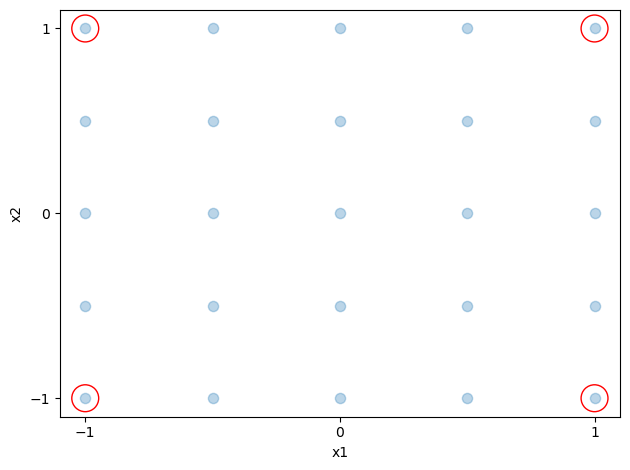

In [7]:
designer.plot_optimal_controls(non_opt_candidates=True)
designer.show_plots()

## Checklist

Copy this block into a new script and fill in what applies:

```python
designer.model_parameter_names      = [...]   # SINGULAR "parameter"
designer.response_names             = [...]
designer.ti_controls_names          = [...]
designer.model_parameter_unit_names = [...]
designer.response_unit_names        = [...]
```

Four things to remember:

1. Set them **before** `initialize()`.
2. `model_parameter_names` is singular — note the "parameter", not
   "parameters".
3. Anything you leave unset gets a generated default, so a run with a failed
   assignment still prints something plausible. Check the report says what you
   meant.